# Recurrent `dy` Sparsity Analysis

This notebook analyzes the `dy` tensors captured from `calculate_synaptic_currents.grad` during one training step. The goal is to decide whether the backward recurrent path has enough effective sparsity to justify thresholding `dy` and replacing the dense-left sparse matmul with a sparse/active-value path.

The dump folder is large, so the notebook uses the summary CSV for fast overview plots and only loads full `.npz` tensors for selected calls.

In [68]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DUMP_DIR = Path("v1_recurrent_dy")
RUN_PID = None  # Set to an integer pid to select a specific dump run.

summary_paths = sorted(DUMP_DIR.glob("*_summary.csv"))
if not summary_paths:
    raise FileNotFoundError(f"No summary CSV found in {DUMP_DIR}")

if RUN_PID is None:
    SUMMARY_PATH = max(summary_paths, key=lambda path: path.stat().st_mtime)
else:
    matches = [path for path in summary_paths if f"pid{RUN_PID}" in path.name]
    if not matches:
        raise FileNotFoundError(f"No summary CSV found for RUN_PID={RUN_PID}")
    SUMMARY_PATH = matches[0]

pid_match = re.search(r"pid(\d+)", SUMMARY_PATH.name)
SELECTED_PID = pid_match.group(1) if pid_match else None
NPZ_FILES = sorted(DUMP_DIR.glob(f"*pid{SELECTED_PID}_call*.npz")) if SELECTED_PID else sorted(DUMP_DIR.glob("*.npz"))

print(f"summary: {SUMMARY_PATH}")
print(f"selected pid: {SELECTED_PID}")
print(f"npz files for selected pid: {len(NPZ_FILES):,}")

summary: v1_recurrent_dy/recurrent_dy_pid1822953_summary.csv
selected pid: 1822953
npz files for selected pid: 278


## Load Summary

`call_index` is the order in which TensorFlow executed the custom-gradient calls during backpropagation. For an RNN, this is usually backward-time order, so call 0 may correspond to the last recurrent timestep rather than the first forward timestep.

In [69]:
summary = pd.read_csv(SUMMARY_PATH).sort_values("call_index").reset_index(drop=True)

threshold_cols = [c for c in summary.columns if c.startswith("frac_le_")]
retained_cols = [c for c in summary.columns if c.startswith("retained_mass_gt_")]

summary["nonzero_frac"] = 1.0 - summary["exact_zero_count"] / summary["total_count"]
summary["all_zero"] = summary["sum_abs"] == 0

display(summary.head())
display(summary.tail())

print("calls:", len(summary))
print("shape(s):", summary["shape"].unique())
print("dtype(s):", summary["dtype"].unique())
print("all-zero calls:", int(summary["all_zero"].sum()))
print("nonzero calls:", int((~summary["all_zero"]).sum()))

,call_index,file_name,shape,dtype,total_count,finite_count,exact_zero_count,sum_abs,mean_abs,max_abs,...,frac_le_1e-05,frac_le_1e-04,retained_mass_gt_0,retained_mass_gt_1e-08,retained_mass_gt_1e-07,retained_mass_gt_1e-06,retained_mass_gt_1e-05,retained_mass_gt_1e-04,nonzero_frac,all_zero
0,0,recurrent_dy_pid1822953_call000000.npz,1222896x4,float16,4891584,4891584,4891584,0.000000,0.000000,0.000000,...,1.000000,1.000000,0,0,0.0,0.000000,0.000000,0.000000,0.000000,True
1,1,recurrent_dy_pid1822953_call000001.npz,1222896x4,float16,4891584,4891584,4891584,0.000000,0.000000,0.000000,...,1.000000,1.000000,0,0,0.0,0.000000,0.000000,0.000000,0.000000,True
2,2,recurrent_dy_pid1822953_call000002.npz,1222896x4,float16,4891584,4891584,66240,7767.311622,0.001588,11.179688,...,0.085372,0.400247,1,1,1.0,0.999994,0.999844,0.989983,0.986458,False
3,3,recurrent_dy_pid1822953_call000003.npz,1222896x4,float16,4891584,4891584,49655,20577.162553,0.004207,25.218750,...,0.052885,0.199466,1,1,1.0,0.999998,0.999973,0.998095,0.989849,False
4,4,recurrent_dy_pid1822953_call000004.npz,1222896x4,float16,4891584,4891584,39077,35352.689182,0.007227,42.593750,...,0.043263,0.130215,1,1,1.0,0.999999,0.999987,0.999327,0.992011,False


,call_index,file_name,shape,dtype,total_count,finite_count,exact_zero_count,sum_abs,mean_abs,max_abs,...,frac_le_1e-05,frac_le_1e-04,retained_mass_gt_0,retained_mass_gt_1e-08,retained_mass_gt_1e-07,retained_mass_gt_1e-06,retained_mass_gt_1e-05,retained_mass_gt_1e-04,nonzero_frac,all_zero
273,273,recurrent_dy_pid1822953_call000273.npz,1222896x4,float16,4891584,4891584,2996,269460.293070,0.055087,411.25,...,0.014805,0.042016,1,1,1.0,1.0,0.999999,0.999975,0.999388,False
274,274,recurrent_dy_pid1822953_call000274.npz,1222896x4,float16,4891584,4891584,3077,269393.820514,0.055073,412.00,...,0.014873,0.042300,1,1,1.0,1.0,0.999999,0.999975,0.999371,False
275,275,recurrent_dy_pid1822953_call000275.npz,1222896x4,float16,4891584,4891584,3036,269372.375281,0.055069,412.00,...,0.014800,0.042380,1,1,1.0,1.0,0.999999,0.999975,0.999379,False
276,276,recurrent_dy_pid1822953_call000276.npz,1222896x4,float16,4891584,4891584,2997,269308.742700,0.055056,411.75,...,0.014660,0.042264,1,1,1.0,1.0,0.999999,0.999975,0.999387,False
277,277,recurrent_dy_pid1822953_call000277.npz,1222896x4,float16,4891584,4891584,2966,269394.777640,0.055073,411.25,...,0.014472,0.042002,1,1,1.0,1.0,0.999999,0.999975,0.999394,False


calls: 278
shape(s): ['1222896x4']
dtype(s): ['float16']
all-zero calls: 2
nonzero calls: 276


## Fast Overview From CSV

These plots answer the first practical question: are the gradients exactly sparse or only approximately sparse, and is the approximate sparsity stable across backward calls?

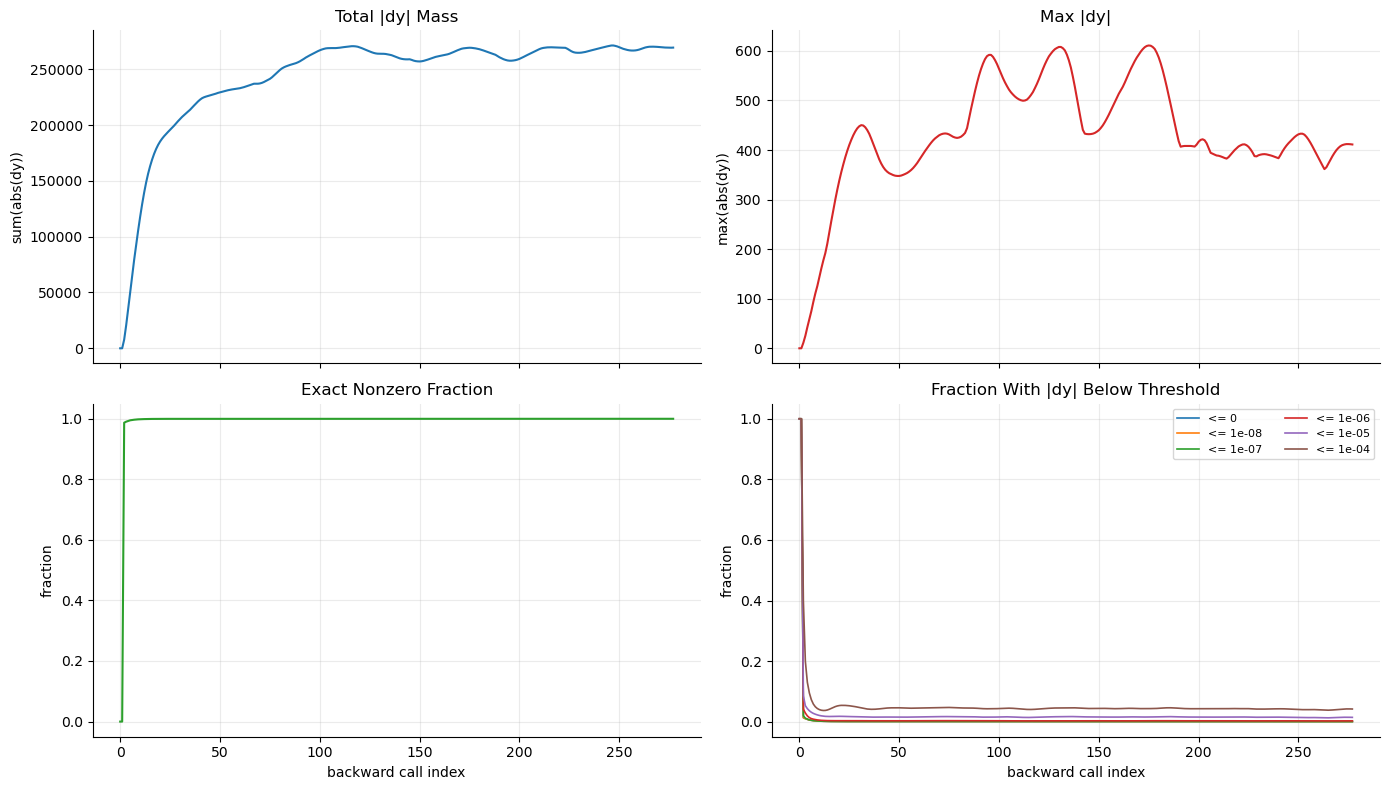

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
x = summary["call_index"]

axes[0, 0].plot(x, summary["sum_abs"], lw=1.5)
axes[0, 0].set_title("Total |dy| Mass")
axes[0, 0].set_ylabel("sum(abs(dy))")

axes[0, 1].plot(x, summary["max_abs"], lw=1.5, color="tab:red")
axes[0, 1].set_title("Max |dy|")
axes[0, 1].set_ylabel("max(abs(dy))")

axes[1, 0].plot(x, summary["nonzero_frac"], lw=1.5, color="tab:green")
axes[1, 0].set_title("Exact Nonzero Fraction")
axes[1, 0].set_xlabel("backward call index")
axes[1, 0].set_ylabel("fraction")

for col in threshold_cols:
    label = col.replace("frac_le_", "<= ")
    axes[1, 1].plot(x, summary[col], lw=1.2, label=label)
axes[1, 1].set_title("Fraction With |dy| Below Threshold")
axes[1, 1].set_xlabel("backward call index")
axes[1, 1].set_ylabel("fraction")
axes[1, 1].legend(ncol=2, fontsize=8)

plt.tight_layout()

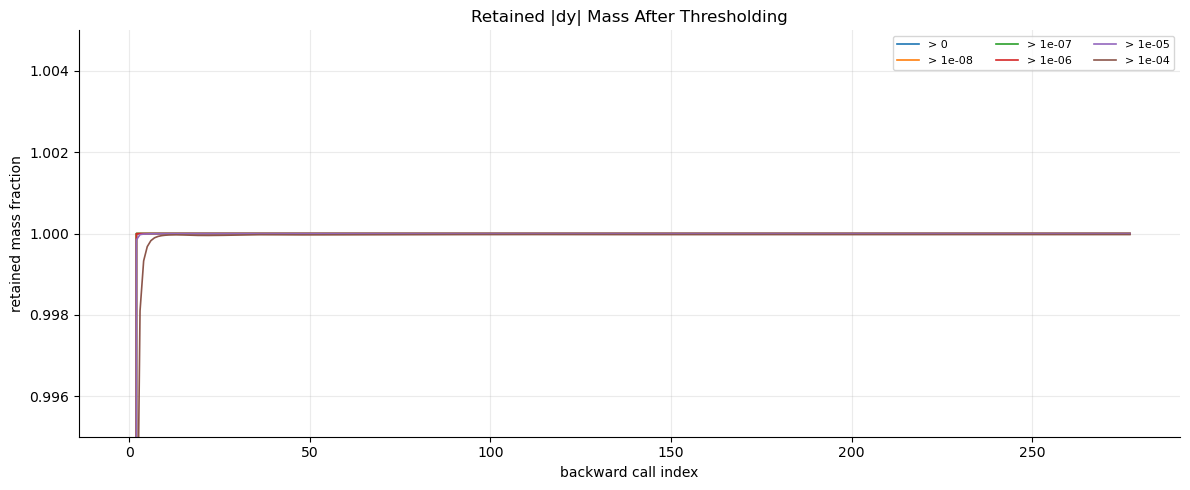

In [71]:
fig, ax = plt.subplots(figsize=(12, 5))
for col in retained_cols:
    label = col.replace("retained_mass_gt_", "> ")
    ax.plot(summary["call_index"], summary[col], lw=1.2, label=label)
ax.set_title("Retained |dy| Mass After Thresholding")
ax.set_xlabel("backward call index")
ax.set_ylabel("retained mass fraction")
ax.set_ylim(0.995, 1.005)
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()

## Threshold Tradeoff Table

A threshold is only attractive if it removes many entries while preserving almost all absolute gradient mass. The table below aggregates across backward calls.

In [72]:
rows = []
for frac_col in threshold_cols:
    suffix = frac_col.replace("frac_le_", "")
    mass_col = f"retained_mass_gt_{suffix}"
    if mass_col not in summary:
        continue
    rows.append({
        "threshold": suffix,
        "median_pruned_fraction": summary[frac_col].median(),
        "p10_pruned_fraction": summary[frac_col].quantile(0.10),
        "p90_pruned_fraction": summary[frac_col].quantile(0.90),
        "median_retained_mass": summary[mass_col].median(),
        "p10_retained_mass": summary[mass_col].quantile(0.10),
        "p90_retained_mass": summary[mass_col].quantile(0.90),
    })

tradeoff = pd.DataFrame(rows)
display(tradeoff)

,threshold,median_pruned_fraction,p10_pruned_fraction,p90_pruned_fraction,median_retained_mass,p10_retained_mass,p90_retained_mass
0,0,0.000658,0.000585,0.000852,1.000000,1.000000,1.000000
1,1e-08,0.000658,0.000585,0.000852,1.000000,1.000000,1.000000
2,1e-07,0.000692,0.000616,0.000888,1.000000,1.000000,1.000000
3,1e-06,0.003090,0.002855,0.003453,1.000000,1.000000,1.000000
4,1e-05,0.015641,0.014421,0.017088,0.999999,0.999998,0.999999
5,1e-04,0.043592,0.040649,0.046915,0.999974,0.999965,0.999976


## Load Selected Full Tensors

The helper below loads one call at a time. Use selected calls for histograms and per-receptor statistics rather than stacking all 3.9 GB into memory.

In [73]:
def npz_path_for_call(call_index):
    row = summary.loc[summary["call_index"] == call_index]
    if row.empty:
        raise KeyError(f"No call_index={call_index}")
    return DUMP_DIR / row.iloc[0]["file_name"]


def load_dy(call_index, as_float32=False):
    path = npz_path_for_call(call_index)
    with np.load(path) as data:
        dy = data["dy"]
        if as_float32:
            dy = dy.astype(np.float32)
        return dy


def pick_representative_calls(n=8):
    nonzero = summary.loc[~summary["all_zero"], "call_index"].to_numpy()
    if len(nonzero) == 0:
        return []
    idx = np.linspace(0, len(nonzero) - 1, min(n, len(nonzero))).round().astype(int)
    return nonzero[idx].tolist()


selected_calls = pick_representative_calls(n=8)
HIGHER_THRESHOLDS = np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1], dtype=np.float32)
higher_threshold_sample_calls = pick_representative_calls(n=25)
selected_calls, higher_threshold_sample_calls

([2, 41, 81, 120, 159, 198, 238, 277],
 [2,
  13,
  25,
  36,
  48,
  59,
  71,
  82,
  94,
  105,
  117,
  128,
  140,
  151,
  162,
  174,
  185,
  197,
  208,
  220,
  231,
  243,
  254,
  266,
  277])

## Higher Threshold Sweep

The summary CSV only contains thresholds up to `1e-4`. To explore the more aggressive regime, this section loads a representative subset of full `dy` tensors and recomputes pruned-entry and retained-mass curves for higher thresholds. This keeps memory use bounded while making the tradeoff visible in the figures.

In [74]:
def compute_threshold_sweep(call_indices, thresholds):
    rows = []
    for call_index in call_indices:
        dy = load_dy(call_index, as_float32=True)
        abs_dy = np.abs(dy)
        total_mass = abs_dy.sum(dtype=np.float64)
        for threshold in thresholds:
            mask = abs_dy <= threshold
            pruned_mass = abs_dy[mask].sum(dtype=np.float64)
            rows.append({
                "call_index": call_index,
                "threshold": float(threshold),
                "pruned_fraction": float(mask.mean()),
                "retained_entry_fraction": float(1.0 - mask.mean()),
                "retained_mass_fraction": float(1.0 - pruned_mass / total_mass) if total_mass else 0.0,
                "sum_abs": float(total_mass),
            })
    return pd.DataFrame(rows)


higher_threshold_sweep = compute_threshold_sweep(
    higher_threshold_sample_calls,
    HIGHER_THRESHOLDS,
)
display(higher_threshold_sweep.head())

,call_index,threshold,pruned_fraction,retained_entry_fraction,retained_mass_fraction,sum_abs
0,2,0.0001,0.400087,0.599913,0.989993,7767.311622
1,2,0.0003,0.639332,0.360668,0.963630,7767.311622
2,2,0.0010,0.779680,0.220320,0.914185,7767.311622
3,2,0.0030,0.900880,0.099120,0.774719,7767.311622
4,2,0.0100,0.982035,0.017965,0.514329,7767.311622


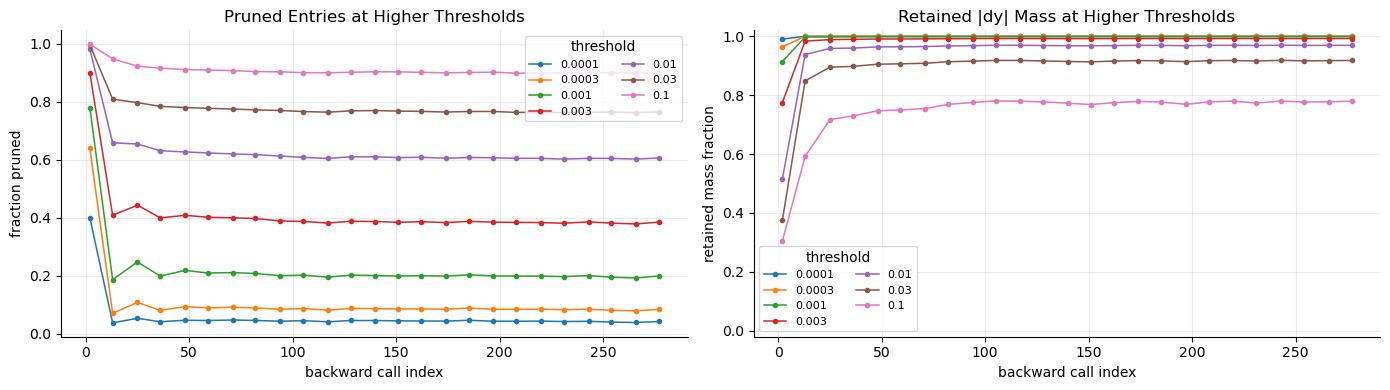

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for threshold, group in higher_threshold_sweep.groupby("threshold"):
    label = f"{threshold:g}"
    axes[0].plot(group["call_index"], group["pruned_fraction"], marker="o", ms=3, lw=1.1, label=label)
    axes[1].plot(group["call_index"], group["retained_mass_fraction"], marker="o", ms=3, lw=1.1, label=label)

axes[0].set_title("Pruned Entries at Higher Thresholds")
axes[0].set_xlabel("backward call index")
axes[0].set_ylabel("fraction pruned")

axes[1].set_title("Retained |dy| Mass at Higher Thresholds")
axes[1].set_xlabel("backward call index")
axes[1].set_ylabel("retained mass fraction")
axes[1].set_ylim(-0.02, 1.02)

for ax in axes:
    ax.legend(title="threshold", ncol=2, fontsize=8)
plt.tight_layout()

In [76]:
higher_threshold_tradeoff = (
    higher_threshold_sweep
    .groupby("threshold")
    .agg(
        median_pruned_fraction=("pruned_fraction", "median"),
        p10_pruned_fraction=("pruned_fraction", lambda x: x.quantile(0.10)),
        p90_pruned_fraction=("pruned_fraction", lambda x: x.quantile(0.90)),
        median_retained_mass=("retained_mass_fraction", "median"),
        p10_retained_mass=("retained_mass_fraction", lambda x: x.quantile(0.10)),
        p90_retained_mass=("retained_mass_fraction", lambda x: x.quantile(0.90)),
    )
    .reset_index()
)
display(higher_threshold_tradeoff)

,threshold,median_pruned_fraction,p10_pruned_fraction,p90_pruned_fraction,median_retained_mass,p10_retained_mass,p90_retained_mass
0,0.0001,0.043184,0.040137,0.046624,0.999974,0.999968,0.999976
1,0.0003,0.084504,0.080482,0.092234,0.999822,0.999759,0.999828
2,0.0010,0.199896,0.194799,0.215063,0.998469,0.997742,0.998522
3,0.0030,0.386636,0.381325,0.408266,0.991989,0.988899,0.992238
4,0.0100,0.608360,0.604651,0.645032,0.968285,0.959087,0.969160
5,0.0300,0.767009,0.763352,0.791976,0.915621,0.896011,0.917652
6,0.1000,0.902047,0.899291,0.920226,0.774182,0.721885,0.779752


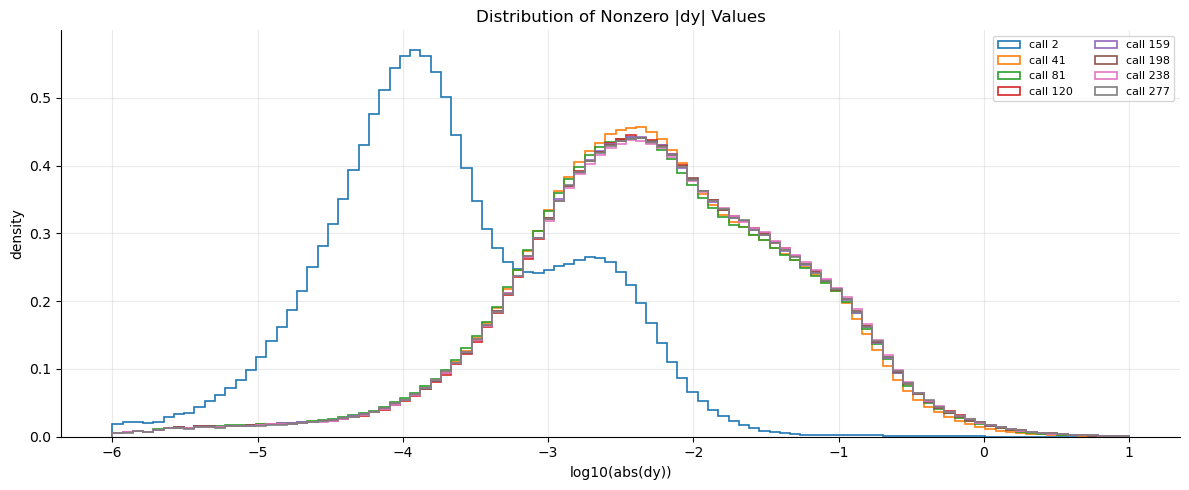

In [77]:
bins = np.r_[-np.inf, np.linspace(-6, 1, 100), np.inf]
fig, ax = plt.subplots(figsize=(12, 5))

for call_index in selected_calls:
    dy = load_dy(call_index)
    abs_values = np.abs(dy.ravel())
    abs_values = abs_values[abs_values > 0]
    if len(abs_values) == 0:
        continue
    log_abs = np.log10(abs_values.astype(np.float32))
    ax.hist(log_abs, bins=bins, histtype="step", density=True, lw=1.2, label=f"call {call_index}")

ax.set_title("Distribution of Nonzero |dy| Values")
ax.set_xlabel("log10(abs(dy))")
ax.set_ylabel("density")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()

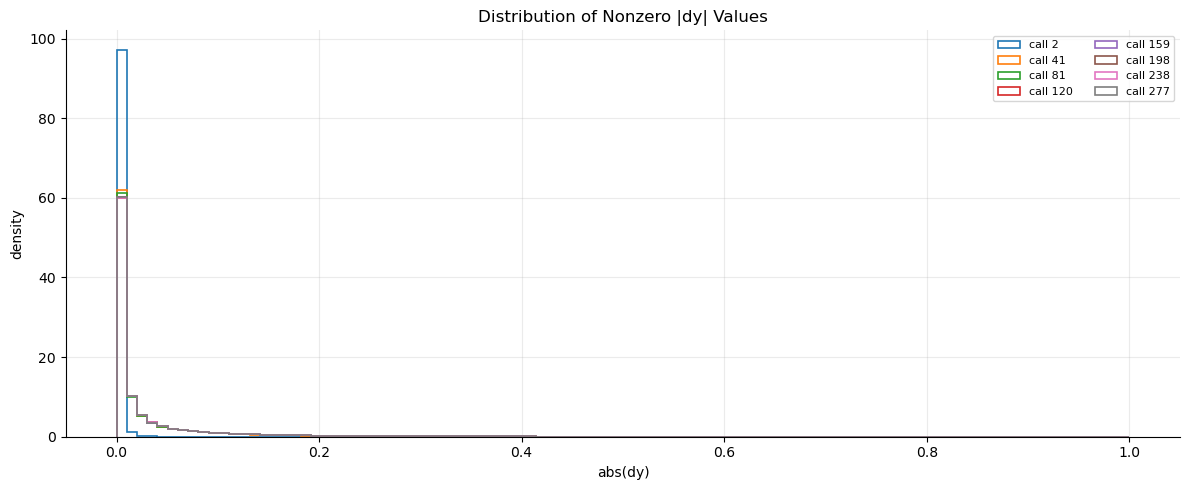

In [78]:
bins = np.r_[-np.inf, np.linspace(0, 1, 100), np.inf]
fig, ax = plt.subplots(figsize=(12, 5))

for call_index in selected_calls:
    dy = load_dy(call_index)
    abs_values = np.abs(dy.ravel())
    abs_values = abs_values[abs_values > 0]
    if len(abs_values) == 0:
        continue
    # log_abs = np.log10(abs_values.astype(np.float32))
    # plot without logscale
    log_abs = abs_values.astype(np.float32)
    ax.hist(log_abs, bins=bins, histtype="step", density=True, lw=1.2, label=f"call {call_index}")

ax.set_title("Distribution of Nonzero |dy| Values")
ax.set_xlabel("abs(dy)")
ax.set_ylabel("density")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()

## Per-Receptor/Basis Analysis

`dy` has shape `[batch_size * n_post_neurons, n_syn_basis]`. The columns correspond to synaptic basis/receptor channels. A sparse backward path may only be useful if all channels show similar threshold behavior, or if we can handle channels independently.

In [79]:
PER_CHANNEL_THRESHOLDS = np.array([0, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 3e-3, 1e-2], dtype=np.float32)

channel_rows = []
for call_index in selected_calls:
    dy = load_dy(call_index)
    abs_dy = np.abs(dy.astype(np.float32))
    for channel in range(abs_dy.shape[1]):
        values = abs_dy[:, channel]
        total_mass = values.sum(dtype=np.float64)
        row = {
            "call_index": call_index,
            "channel": channel,
            "sum_abs": total_mass,
            "mean_abs": values.mean(dtype=np.float64),
            "max_abs": values.max(),
            "exact_nonzero_frac": np.count_nonzero(values) / values.size,
        }
        for threshold in PER_CHANNEL_THRESHOLDS:
            mask = values <= threshold
            row[f"frac_le_{threshold:g}"] = mask.mean()
            row[f"retained_mass_gt_{threshold:g}"] = 1 - values[mask].sum(dtype=np.float64) / total_mass if total_mass else 0
        channel_rows.append(row)

channel_summary = pd.DataFrame(channel_rows)
display(channel_summary.head())

,call_index,channel,sum_abs,mean_abs,max_abs,exact_nonzero_frac,frac_le_0,retained_mass_gt_0,frac_le_1e-07,retained_mass_gt_1e-07,...,frac_le_1e-05,retained_mass_gt_1e-05,frac_le_0.0001,retained_mass_gt_0.0001,frac_le_0.001,retained_mass_gt_0.001,frac_le_0.003,retained_mass_gt_0.003,frac_le_0.01,retained_mass_gt_0.01
0,2,0,2753.251325,0.002251,11.179688,0.985232,0.014768,1.0,0.014768,1.0,...,0.067254,0.999930,0.298858,0.994626,0.737880,0.933189,0.854037,0.837537,0.970365,0.565216
1,2,1,2338.320058,0.001912,9.492188,0.987685,0.012315,1.0,0.017194,1.0,...,0.072490,0.999904,0.334161,0.992920,0.754619,0.925110,0.874085,0.808504,0.976920,0.533709
2,2,2,1566.369906,0.001281,6.359375,0.987685,0.012315,1.0,0.019534,1.0,...,0.089549,0.999794,0.436845,0.986277,0.794751,0.899340,0.922118,0.716272,0.987748,0.465383
3,2,3,1109.370334,0.000907,4.503906,0.985232,0.014768,1.0,0.021663,1.0,...,0.110794,0.999594,0.530484,0.977572,0.831470,0.864956,0.953280,0.630132,0.993107,0.416296
4,41,0,17799.242283,0.014555,49.000000,0.997233,0.002767,1.0,0.002767,1.0,...,0.030326,0.999994,0.074937,0.999834,0.374291,0.989456,0.600358,0.962387,0.758063,0.900601


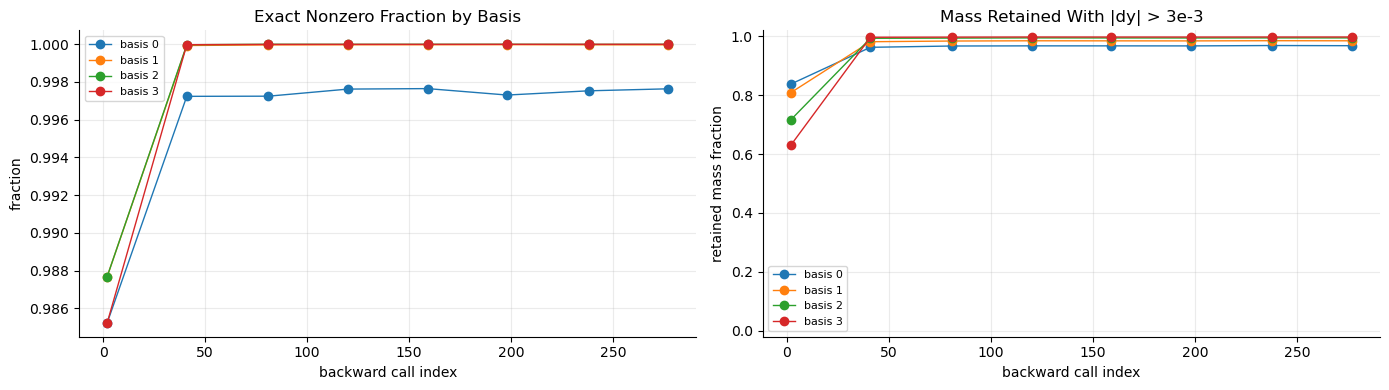

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for channel, group in channel_summary.groupby("channel"):
    axes[0].plot(group["call_index"], group["exact_nonzero_frac"], marker="o", lw=1, label=f"basis {channel}")
    axes[1].plot(group["call_index"], group["retained_mass_gt_0.003"], marker="o", lw=1, label=f"basis {channel}")

axes[0].set_title("Exact Nonzero Fraction by Basis")
axes[0].set_xlabel("backward call index")
axes[0].set_ylabel("fraction")

axes[1].set_title("Mass Retained With |dy| > 3e-3")
axes[1].set_xlabel("backward call index")
axes[1].set_ylabel("retained mass fraction")
axes[1].set_ylim(-0.02, 1.02)

for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()

## Candidate Sparsification Rule

This cell estimates how many entries would remain under candidate thresholds. For a sparse-left implementation to be worth pursuing, the retained fraction probably needs to be very small after accounting for the overhead of thresholding, `tf.where`, sparse index construction, and sparse kernels.

In [81]:
csv_candidate_thresholds = [0, 1e-7, 1e-6, 1e-5, 1e-4]
candidate_rows = []

for threshold in csv_candidate_thresholds:
    frac_col = f"frac_le_{threshold:.0e}" if threshold != 0 else "frac_le_0"
    mass_col = f"retained_mass_gt_{threshold:.0e}" if threshold != 0 else "retained_mass_gt_0"
    if frac_col not in summary or mass_col not in summary:
        continue
    retained_fraction = 1.0 - summary[frac_col]
    candidate_rows.append({
        "source": "all calls (CSV)",
        "threshold": threshold,
        "median_retained_entries": retained_fraction.median(),
        "p90_retained_entries": retained_fraction.quantile(0.90),
        "median_retained_mass": summary[mass_col].median(),
        "min_retained_mass": summary[mass_col].min(),
        "n_calls": len(summary),
    })

for threshold, group in higher_threshold_sweep.groupby("threshold"):
    candidate_rows.append({
        "source": "sampled full dy",
        "threshold": threshold,
        "median_retained_entries": group["retained_entry_fraction"].median(),
        "p90_retained_entries": group["retained_entry_fraction"].quantile(0.90),
        "median_retained_mass": group["retained_mass_fraction"].median(),
        "min_retained_mass": group["retained_mass_fraction"].min(),
        "n_calls": len(group),
    })

candidate_table = (
    pd.DataFrame(candidate_rows)
    .drop_duplicates(subset=["source", "threshold"])
    .sort_values(["threshold", "source"])
    .reset_index(drop=True)
)
display(candidate_table)

,source,threshold,median_retained_entries,p90_retained_entries,median_retained_mass,min_retained_mass,n_calls
0,all calls (CSV),0.000000e+00,0.999342,0.999415,1.000000,0.000000,278
1,all calls (CSV),1.000000e-07,0.999308,0.999384,1.000000,0.000000,278
2,all calls (CSV),1.000000e-06,0.996910,0.997145,1.000000,0.000000,278
3,all calls (CSV),1.000000e-05,0.984359,0.985579,0.999999,0.000000,278
4,sampled full dy,1.000000e-04,0.956816,0.959863,0.999974,0.989993,25
5,all calls (CSV),1.000000e-04,0.956408,0.959351,0.999974,0.000000,278
6,sampled full dy,3.000000e-04,0.915496,0.919518,0.999822,0.963630,25
7,sampled full dy,1.000000e-03,0.800104,0.805201,0.998469,0.914185,25
8,sampled full dy,3.000000e-03,0.613364,0.618675,0.991989,0.774719,25
9,sampled full dy,1.000000e-02,0.391640,0.395349,0.968285,0.514329,25


## Notes For Interpretation

- Exact zeros are the cleanest target because they do not change the gradient, but they may not be enough to win unless the retained fraction is very low.
- Near-zero thresholding changes the gradient. A promising threshold should remove many entries while preserving nearly all `sum(abs(dy))` across most calls and basis channels.
- The cost of thresholding is not free: the current dense `dy_r @ sparse_w_rec` path scans dense `dy`, and a sparse alternative would also scan dense `dy` to discover active entries unless we can derive sparsity earlier in the graph.
- A good next experiment after this notebook is to prototype thresholding on saved tensors offline and compare `dy @ W_sparse` against the thresholded approximation for several calls.

## Effect of Thresholding on `de_dv`

The previous sections measure sparsity and retained `|dy|` mass. This section checks the quantity that actually matters in `models.py`: the recurrent gradient with respect to the spike buffer,

```python
for r_id in range(n_syn_basis):
    dy_r = reshape(dy[:, r_id], [batch_size, n_post_neurons])
    weights_syn_receptors = weight_values_compute * synaptic_basis_weights[syn_ids, r_id]
    de_dv += sparse_dense_matmul(dy_r, sparse_w_rec)
```

For selected calls, we compute the baseline `de_dv` with the dense `dy`, then recompute it after thresholding small `dy` values. This gives an offline estimate of how much the proposed sparsification would perturb the backward signal.

This loads the recurrent connectivity and weights from the cached network pickle. It is memory-heavy because the full recurrent graph has tens of millions of synapses.

In [89]:
import pickle as pkl
from scipy import sparse

NETWORK_CACHE_PATH = Path("GLIF_network_nll_full/tf_data/V1_network_v1_203816.pkl")
SYNAPTIC_BASIS_PATH = NETWORK_CACHE_PATH.parent / "syn_id_to_syn_weights_dict.pkl"

# Keep this modest: each call requires several sparse products over the full recurrent graph.
DE_DV_SAMPLE_CALLS = pick_representative_calls(n=6)
DE_DV_THRESHOLDS = np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1], dtype=np.float32)

print("network cache:", NETWORK_CACHE_PATH)
print("basis cache:", SYNAPTIC_BASIS_PATH)
print("sample calls:", DE_DV_SAMPLE_CALLS)
print("thresholds:", DE_DV_THRESHOLDS)

network cache: GLIF_network_nll_full/tf_data/V1_network_v1_203816.pkl
basis cache: GLIF_network_nll_full/tf_data/syn_id_to_syn_weights_dict.pkl
sample calls: [2, 57, 112, 167, 222, 277]
thresholds: [1.e-04 3.e-04 1.e-03 3.e-03 1.e-02 3.e-02 1.e-01]


In [90]:
def load_recurrent_data_for_de_dv(network_cache_path=NETWORK_CACHE_PATH, basis_path=SYNAPTIC_BASIS_PATH):
    with open(network_cache_path, "rb") as handle:
        cached = pkl.load(handle)
    network = cached[0] if isinstance(cached, tuple) else cached
    synapses = network["synapses"]

    with open(basis_path, "rb") as handle:
        syn_id_to_syn_weights_dict = pkl.load(handle)

    recurrent = {
        "indices": np.asarray(synapses["indices"], dtype=np.int64),
        "weights": np.asarray(synapses["weights"], dtype=np.float32),
        "syn_ids": np.asarray(synapses["syn_ids"], dtype=np.int64),
        "dense_shape": tuple(int(x) for x in synapses["dense_shape"]),
        "basis": np.asarray(list(syn_id_to_syn_weights_dict.values()), dtype=np.float32),
        "n_nodes": int(network["n_nodes"]),
    }
    return recurrent


recurrent = load_recurrent_data_for_de_dv()
print("n_nodes:", recurrent["n_nodes"])
print("dense_shape:", recurrent["dense_shape"])
print("n_synapses:", recurrent["weights"].shape[0])
print("n_basis:", recurrent["basis"].shape[1])

first_dy = load_dy(DE_DV_SAMPLE_CALLS[0])
batch_size_for_de_dv = first_dy.shape[0] // recurrent["dense_shape"][0]
assert first_dy.shape[0] == batch_size_for_de_dv * recurrent["dense_shape"][0]
assert first_dy.shape[1] == recurrent["basis"].shape[1]
print("inferred batch_size:", batch_size_for_de_dv)

n_nodes: 203816
dense_shape: (203816, 203816)
n_synapses: 84132910
n_basis: 4
inferred batch_size: 6


In [91]:
def build_receptor_sparse_matrices(recurrent):
    indices = recurrent["indices"]
    post = indices[:, 0]
    pre = indices[:, 1]
    weights = recurrent["weights"]
    syn_ids = recurrent["syn_ids"]
    basis = recurrent["basis"]
    dense_shape = recurrent["dense_shape"]

    matrices = []
    for r_id in range(basis.shape[1]):
        receptor_weights = weights * basis[syn_ids, r_id]
        matrices.append(
            sparse.csr_matrix(
                (receptor_weights, (post, pre)),
                shape=dense_shape,
                dtype=np.float32,
            )
        )
    return matrices


receptor_sparse_matrices = build_receptor_sparse_matrices(recurrent)
print("built receptor sparse matrices:", len(receptor_sparse_matrices))

built receptor sparse matrices: 4


In [92]:
def compute_de_dv_numpy(dy, receptor_sparse_matrices, threshold=None):
    dy = dy.astype(np.float32, copy=False)
    if threshold is not None and threshold > 0:
        dy = dy.copy()
        dy[np.abs(dy) <= threshold] = 0.0

    n_post = receptor_sparse_matrices[0].shape[0]
    batch_size = dy.shape[0] // n_post
    n_pre = receptor_sparse_matrices[0].shape[1]
    de_dv = np.zeros((batch_size, n_pre), dtype=np.float32)

    for r_id, sparse_w_rec in enumerate(receptor_sparse_matrices):
        dy_r = dy[:, r_id].reshape(batch_size, n_post)
        de_dv += dy_r @ sparse_w_rec

    return de_dv


def summarize_de_dv_error(reference, approximation):
    diff = approximation - reference
    ref_norm = np.linalg.norm(reference.ravel())
    diff_norm = np.linalg.norm(diff.ravel())
    abs_diff = np.abs(diff)
    abs_ref = np.abs(reference)
    return {
        "relative_l2_error": diff_norm / ref_norm if ref_norm else 0.0,
        "mean_abs_error": float(abs_diff.mean()),
        "median_abs_error": float(np.median(abs_diff)),
        "p95_abs_error": float(np.quantile(abs_diff, 0.95)),
        "max_abs_error": float(abs_diff.max()),
        "mean_abs_reference": float(abs_ref.mean()),
        "max_abs_reference": float(abs_ref.max()),
        "reference_nonzero_fraction": float(np.count_nonzero(reference) / reference.size),
    }

In [93]:
de_dv_error_rows = []

for call_index in DE_DV_SAMPLE_CALLS:
    dy = load_dy(call_index, as_float32=True)
    reference = compute_de_dv_numpy(dy, receptor_sparse_matrices, threshold=None)
    dy_abs = np.abs(dy)
    dy_mass = dy_abs.sum(dtype=np.float64)

    for threshold in DE_DV_THRESHOLDS:
        approximation = compute_de_dv_numpy(dy, receptor_sparse_matrices, threshold=float(threshold))
        row = summarize_de_dv_error(reference, approximation)
        mask = dy_abs <= threshold
        row.update({
            "call_index": call_index,
            "threshold": float(threshold),
            "dy_pruned_fraction": float(mask.mean()),
            "dy_retained_mass_fraction": float(1.0 - dy_abs[mask].sum(dtype=np.float64) / dy_mass) if dy_mass else 0.0,
        })
        de_dv_error_rows.append(row)


de_dv_error_summary = pd.DataFrame(de_dv_error_rows)
display(de_dv_error_summary.head())

,relative_l2_error,mean_abs_error,median_abs_error,p95_abs_error,max_abs_error,mean_abs_reference,max_abs_reference,reference_nonzero_fraction,call_index,threshold,dy_pruned_fraction,dy_retained_mass_fraction
0,0.005352,0.054346,0.029789,0.173163,1.023611,10.343727,572.640808,1.0,2,0.0001,0.400087,0.989993
1,0.019719,0.222046,0.134299,0.610207,3.694016,10.343727,572.640808,1.0,2,0.0003,0.639332,0.963630
2,0.045100,0.626994,0.467295,1.740814,6.322670,10.343727,572.640808,1.0,2,0.0010,0.779680,0.914185
3,0.135334,1.542661,0.983257,4.141265,30.251545,10.343727,572.640808,1.0,2,0.0030,0.900880,0.774719
4,0.352482,3.996168,2.090246,11.797400,84.002266,10.343727,572.640808,1.0,2,0.0100,0.982035,0.514329


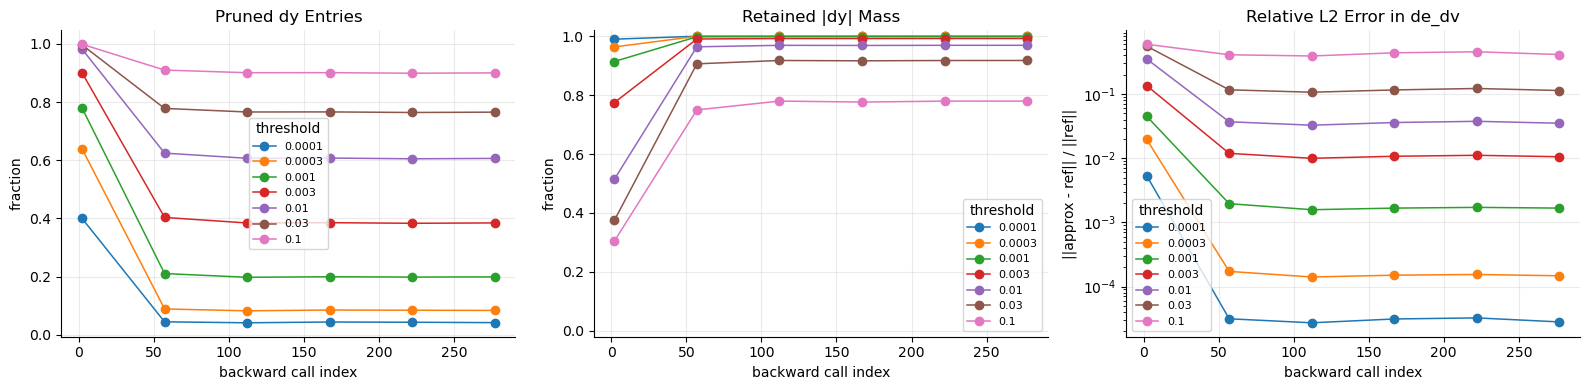

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for threshold, group in de_dv_error_summary.groupby("threshold"):
    label = f"{threshold:g}"
    axes[0].plot(group["call_index"], group["dy_pruned_fraction"], marker="o", lw=1.1, label=label)
    axes[1].plot(group["call_index"], group["dy_retained_mass_fraction"], marker="o", lw=1.1, label=label)
    axes[2].plot(group["call_index"], group["relative_l2_error"], marker="o", lw=1.1, label=label)

axes[0].set_title("Pruned dy Entries")
axes[0].set_xlabel("backward call index")
axes[0].set_ylabel("fraction")

axes[1].set_title("Retained |dy| Mass")
axes[1].set_xlabel("backward call index")
axes[1].set_ylabel("fraction")
axes[1].set_ylim(-0.02, 1.02)

axes[2].set_title("Relative L2 Error in de_dv")
axes[2].set_xlabel("backward call index")
axes[2].set_ylabel("||approx - ref|| / ||ref||")
axes[2].set_yscale("log")

for ax in axes:
    ax.legend(title="threshold", fontsize=8)
plt.tight_layout()

In [95]:
de_dv_threshold_tradeoff = (
    de_dv_error_summary
    .groupby("threshold")
    .agg(
        median_dy_pruned_fraction=("dy_pruned_fraction", "median"),
        median_dy_retained_mass=("dy_retained_mass_fraction", "median"),
        median_relative_l2_error=("relative_l2_error", "median"),
        p90_relative_l2_error=("relative_l2_error", lambda x: x.quantile(0.90)),
        median_p95_abs_error=("p95_abs_error", "median"),
        median_max_abs_error=("max_abs_error", "median"),
    )
    .reset_index()
)
display(de_dv_threshold_tradeoff)

,threshold,median_dy_pruned_fraction,median_dy_retained_mass,median_relative_l2_error,p90_relative_l2_error,median_p95_abs_error,median_max_abs_error
0,0.0001,0.043685,0.999975,0.000031,0.002692,0.008966,0.142149
1,0.0003,0.084925,0.999825,0.000152,0.009945,0.047784,0.457011
2,0.0010,0.199338,0.998500,0.001690,0.023528,0.472082,4.183767
3,0.0030,0.385077,0.992142,0.010906,0.073617,3.141507,22.682507
4,0.0100,0.607162,0.968878,0.036446,0.195019,14.551649,68.653801
5,0.0300,0.765994,0.917054,0.116102,0.339770,36.920508,250.084839
6,0.1000,0.900941,0.778084,0.425787,0.525919,134.280844,1022.378601


Interpretation guide:

- `dy_retained_mass_fraction` close to 1 means the threshold preserves most absolute upstream gradient mass.
- `relative_l2_error` measures the actual downstream perturbation in `de_dv`, after multiplying by recurrent weights and summing receptor channels.
- A threshold is only attractive if it prunes enough entries to plausibly overcome sparse-construction overhead while keeping `relative_l2_error` acceptably small.
- This uses cached recurrent weights. If the training run restored or updated recurrent weights before the dump, load the matching checkpoint weights before treating these numbers as exact.